<a href="https://colab.research.google.com/github/Ropafadzo-Choto1/FUTURE_DS_02/blob/main/Ravenstack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = "ravenstack_data.xlsx"

accounts = pd.read_csv("/content/ravenstack_accounts.csv")
churn = pd.read_csv("/content/ravenstack_churn_events.csv")
usage = pd.read_csv("/content/ravenstack_feature_usage.csv")
subscriptions = pd.read_csv("/content/ravenstack_subscriptions.csv")
tickets = pd.read_csv("/content/ravenstack_support_tickets.csv")

In [ ]:
accounts.head()
usage.head()
subscriptions.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [ ]:
accounts.isnull().sum()
usage.isnull().sum()
subscriptions.isnull().sum()
tickets.isnull().sum()

,0
ticket_id,0
account_id,0
submitted_at,0
closed_at,0
resolution_time_hours,0
priority,0
first_response_time_minutes,0
satisfaction_score,825
escalation_flag,0


No missing values except satisfaction scores which is customer rating after helping a customer



In [ ]:
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
usage['usage_date'] = pd.to_datetime(usage['usage_date'])
tickets['submitted_at'] = pd.to_datetime(tickets['submitted_at'])

In [ ]:
accounts['industry'].value_counts()

,count
industry,
DevTools,113
FinTech,112
Cybersecurity,100
HealthTech,96
EdTech,79


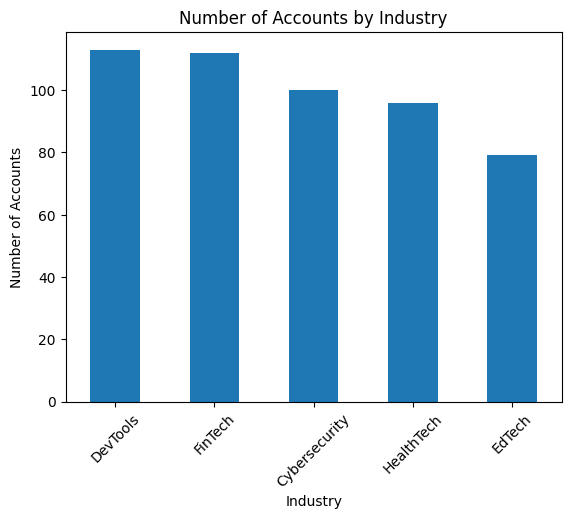

In [ ]:
# Count accounts per industry
industry_counts = accounts['industry'].value_counts()


industry_counts.plot(kind='bar')

plt.title("Number of Accounts by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Accounts")
plt.xticks(rotation=45)

plt.show()

This indicates that the business primarily serves technology-driven industries, with DevTools and FinTech representing the largest customer segments.

In [ ]:
accounts['referral_source'].value_counts()

,count
referral_source,
organic,114
other,103
ads,98
event,96
partner,89


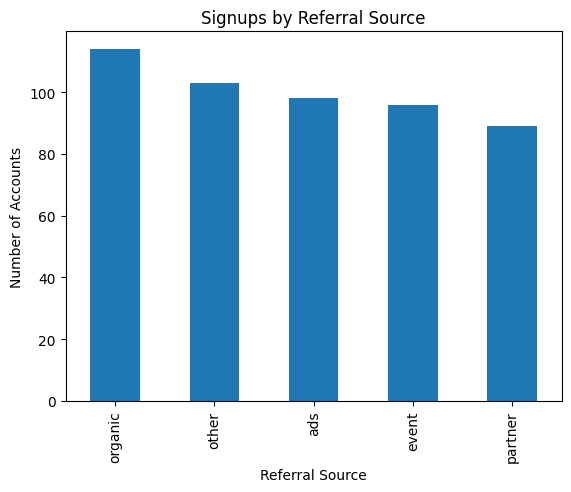

In [ ]:
referrals = accounts['referral_source'].value_counts()

plt.figure()
referrals.plot(kind='bar')
plt.title("Signups by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Number of Accounts")
plt.show()

Insight:
Organic channels generate the most customers, suggesting strong brand visibility or word-of-mouth marketing.

**Product Usage & Feature Engagement**

In [ ]:
usage.groupby("feature_name")["usage_count"].sum().sort_values(ascending=False)

,usage_count
feature_name,
feature_32,6686
feature_15,6621
feature_6,6546
feature_20,6541
feature_34,6536
feature_12,6534
feature_11,6533
feature_2,6525
feature_38,6478


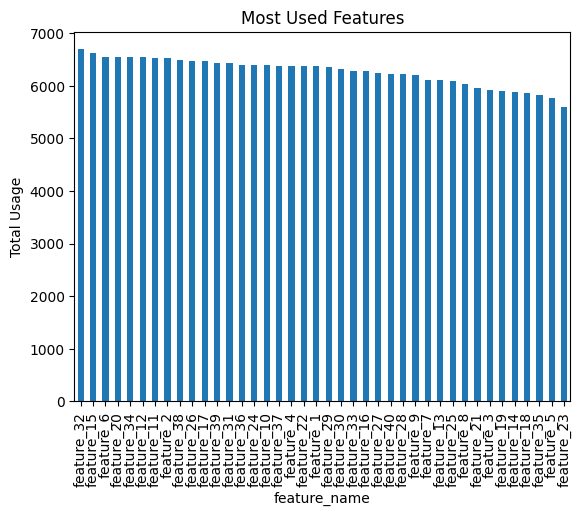

In [ ]:
feature_usage = usage.groupby("feature_name")["usage_count"].sum().sort_values(ascending=False)

plt.figure()
feature_usage.plot(kind='bar')
plt.title("Most Used Features")
plt.ylabel("Total Usage")
plt.show()

Most Used Features

Top features by usage:

feature_32 (6,686 uses)
feature_15 (6,621 uses)
feature_6 (6,546 uses)
feature_20 (6,541 uses)
feature_34 (6,536 uses)

This indicates high engagement across core platform features.


**Feature Error Rates**

In [ ]:
feature_errors = usage.groupby("feature_name")["error_count"].sum()

feature_errors.sort_values(ascending=False)

,error_count
feature_name,
feature_4,418
feature_26,417
feature_9,404
feature_2,401
feature_34,397
feature_16,396
feature_40,380
feature_13,372
feature_29,371


In [ ]:
# Total usage per feature
feature_usage = usage.groupby("feature_name")["usage_count"].sum()

# Total errors per feature
feature_errors = usage.groupby("feature_name")["error_count"].sum()

# Combine both into one table
feature_summary = pd.concat([feature_usage, feature_errors], axis=1)

# Rename columns for clarity
feature_summary.columns = ["Total_Usage", "Total_Errors"]

# Sort by most used features
feature_summary = feature_summary.sort_values(by="Total_Usage", ascending=False)

feature_summary["Error_Rate_%"] = (
    feature_summary["Total_Errors"] / feature_summary["Total_Usage"]) * 100

print(feature_summary)

              Total_Usage  Total_Errors  Error_Rate_%
feature_name                                         
feature_32           6686           357      5.339515
feature_15           6621           349      5.271107
feature_6            6546           339      5.178735
feature_20           6541           308      4.708760
feature_34           6536           397      6.074051
feature_12           6534           359      5.494337
feature_11           6533           352      5.388030
feature_2            6525           401      6.145594
feature_38           6478           356      5.495523
feature_26           6470           417      6.445131
feature_17           6458           369      5.713843
feature_39           6430           357      5.552100
feature_31           6425           335      5.214008
feature_36           6389           371      5.806856
feature_24           6388           349      5.463369
feature_10           6384           348      5.451128
feature_37           6380   

Feature	Error Rate
feature_4	6.56%
feature_9	6.51%
feature_26	6.45%
feature_16	6.31%
feature_18	6.31%

Insight

Features with higher error rates may negatively affect user experience and contribute to churn.

**Customer Support & Service Performance**

In [ ]:
tickets['priority'].value_counts()

,count
priority,
urgent,514
high,510
medium,491
low,485


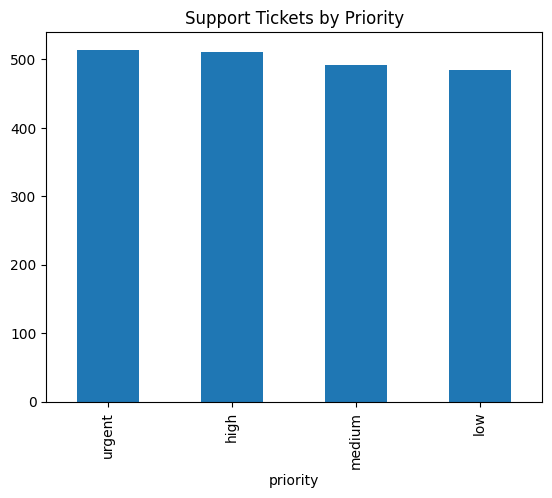

In [ ]:
priority_counts = tickets['priority'].value_counts()

plt.figure()
priority_counts.plot(kind='bar')
plt.title("Support Tickets by Priority")
plt.show()

In [ ]:
avg = tickets['resolution_time_hours'].mean()
hours = int(avg)
minutes = int((avg - hours) * 60)

print(f"{hours} hours {minutes} minutes")

35 hours 51 minutes


In [ ]:
avg_score = tickets['satisfaction_score'].mean()
max_score = tickets['satisfaction_score'].max()

print(f"Satisfaction Score: {avg_score:.2f} / {max_score}")

Satisfaction Score: 3.98 / 5.0


In [ ]:
ticket_counts = tickets.groupby("account_id").size().reset_index(name="ticket_count")

merged_support = accounts.merge(ticket_counts, on="account_id", how="left")

merged_support.groupby("churn_flag")["ticket_count"].mean()

,ticket_count
churn_flag,
False,4.083333
True,4.000000


Support Metrics
Average ticket resolution time:
35 hours 51 minutes
Average satisfaction score:
3.98 / 5

Ticket counts are similar between churned and retained customers, suggesting that ticket volume alone does not predict churn.
However, ticket quality, response time, and resolution satisfaction may matter more.

**Revenue & Customer Lifetime Value**

In [ ]:
total_mrr = subscriptions['mrr_amount'].sum()

print(f"Total MRR: ${total_mrr:,.2f}")

Total MRR: $11,338,747.00


In [ ]:
avg_mrr = subscriptions['mrr_amount'].mean()
print(f"${avg_mrr:,.2f}")

$2,267.75


In [ ]:
arr = subscriptions["mrr_amount"].sum() * 12
print(f"ARR: ${arr:,.2f}")

ARR: $136,064,964.00


In [ ]:
churn_rate = accounts["churn_flag"].mean()
ltv = avg_mrr * (1 / churn_rate)

print(f"Customer Lifetime Value: ${ltv:,.2f}")

Customer Lifetime Value: $10,307.95


Key financial metrics:

Total Monthly Recurring Revenue (MRR):
$11,338,747
Annual Recurring Revenue (ARR):
$136,064,964
Average Customer Lifetime Value (CLV):
$10,307.95

Insight

A CLV of over $10,000 per customer indicates that customer retention is extremely valuable, making churn reduction a major financial opportunity.

**Subscription Plan Distribution**

In [ ]:
subscriptions['plan_tier'].value_counts()

,count
plan_tier,
Enterprise,1723
Pro,1675
Basic,1602


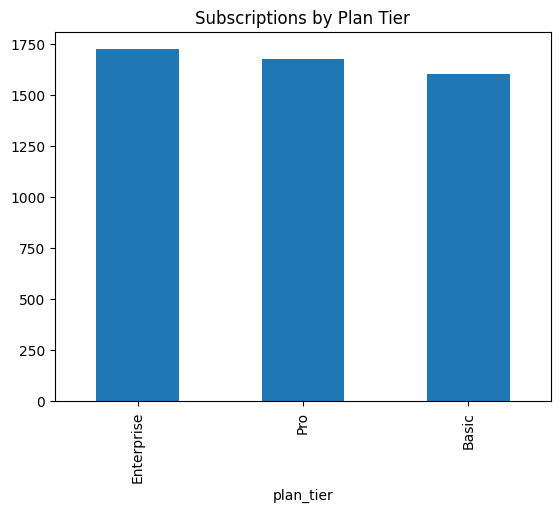

In [ ]:
plan_counts = subscriptions['plan_tier'].value_counts()

plt.figure()
plan_counts.plot(kind='bar')
plt.title("Subscriptions by Plan Tier")
plt.show()

The customer base is relatively balanced across pricing tiers, indicating a diverse mix of enterprise and smaller clients.

In [ ]:
upgrade_rate = subscriptions['upgrade_flag'].mean()
churn_rate = accounts['churn_flag'].mean()
print(f"Churn Rate: {churn_rate * 100:.2f}%")
print(f"Upgrade Rate: {upgrade_rate * 100:.2f}%")

Churn Rate: 22.00%
Upgrade Rate: 10.58%


The upgrade rate (10.58%) indicates strong product value for some users, particularly those who grow with the platform.
However, the churn rate (22%) is more than double the upgrade rate, meaning that the company is losing customers faster than it is expanding revenue through upgrades.

**Main Reasons for Churn**

In [ ]:
total_subscriptions = subscriptions.shape[0]
print("Total Subscriptions:", total_subscriptions)

Total Subscriptions: 5000


In [ ]:
# o DataFrame with only counts
churn_counts = churn['reason_code'].value_counts()
churn_table = churn_counts.to_frame(name="Count")

# Add total row
churn_table.loc["Total"] = churn_table["Count"].sum()

print(churn_table)

             Count
reason_code       
features       114
support        104
budget         104
unknown         95
competitor      92
pricing         91
Total          600


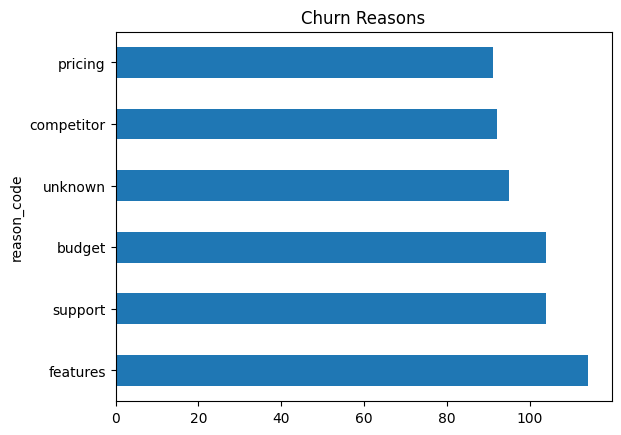

In [ ]:
churn_reasons = churn['reason_code'].value_counts()

plt.figure()
churn_reasons.plot(kind='barh')
plt.title("Churn Reasons")
plt.show()

Out of 5,000 total subscriptions, 600 customers churned, resulting in a churn rate of approximately 12%.

Key Churn Insights
Product limitations are the leading driver of churn
Feature-related complaints are the largest category.
Customers may feel that the platform lacks functionality or innovation.
Customer support issues also contribute significantly
Poor support experiences can negatively affect retention.
Price sensitivity is another driver
Budget and pricing-related churn together represent a large portion of churn.
Competition is also a factor
Customers may be switching to competing platforms with better pricing or features.

In [ ]:
usage_per_account = usage.groupby("subscription_id")["usage_count"].sum().reset_index()

merged = subscriptions.merge(usage_per_account, on="subscription_id", how="left")
merged = merged.merge(accounts, on="account_id")


In [ ]:
merged.groupby("churn_flag_y")["usage_count"].mean()

,usage_count
churn_flag_y,
False,50.234391
True,51.134461


Insight

Feature usage is very similar between churned and retained customers, indicating that:

churn is not driven by lack of engagement
churn is more likely driven by product quality, pricing, or feature gaps

In [ ]:
accounts['is_trial'].value_counts()

,count
is_trial,
False,403
True,97


This suggests that most customers convert directly without a trial, which may indicate strong product demand but also highlights an opportunity to expand trial-based acquisition strategies.

**Key Retention Drivers**

Based on the analysis, the main factors driving retention include:

1. Product Quality
Features with lower error rates improve user satisfaction.
2. Feature Availability
The top churn reason is missing or insufficient features.
3. Customer Support Experience
Support-related churn indicates a need for faster resolution and better service quality.
4. Pricing Strategy
Budget and pricing-related churn suggests price sensitivity among some customer segments.

**Customer Lifetime Trends**

With an average CLV of $10,307.95, long-term customers generate significant value for the business.

Key observations:

Customers actively use the platform features.
Churn is driven more by product quality and value perception rather than lack of engagement.

This indicates that improving product stability, feature development, and support services could significantly extend customer lifetimes.

**Strategic Recommendations**

Improve Product Features

Since feature limitations are the top churn reason, the company should:

prioritize feature requests
improve product roadmap transparency
enhance innovation in core features

**Reduce Feature Errors**

Focus engineering efforts on fixing high-error features such as:

feature_4
feature_9
feature_26
feature_16

Reducing errors will improve user experience and retention.

**Strengthen Customer Support**

Improvements could include:

faster response times
proactive support
improved onboarding and help documentation
Optimize Pricing Strategy

Since pricing contributes to churn:

introduce flexible pricing tiers
offer loyalty discounts
bundle high-value features

**Conclusion**

The analysis shows that customer churn is primarily driven by feature limitations, support issues, and pricing concerns, rather than lack of product usage. Customers actively engage with the platform, but improvements in product functionality, stability, and service quality could significantly enhance retention. Given the high customer lifetime value and recurring revenue, reducing churn even slightly could lead to substantial revenue growth and long-term customer relationships.